# COMPARE DATASETS

Correlations between this study's BII and comparison datasets (NHM BII, gHM, BII4Africa), sampled by continent and by biome (`data/compare/sampled_*.parquet`).

All layers are put on a 0–1 intactness scale: NHM BII is divided by 100, and gHM (human modification) is inverted to `1 - gHM`. Each panel reports Pearson `r` and mean absolute error (MAE), and the same stats are printed as tables at the end.

In [1]:
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

A4 = (8.27, 11.69)  # portrait inches
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
continent = pd.read_parquet("../data/compare/sampled_continent.parquet")
biome = pd.read_parquet("../data/compare/sampled_biome.parquet")
for df in (continent, biome):
    df["nhm_bii"] /= 100  # 0-100 -> 0-1
    df["ghm"] = 1 - df["ghm"]  # human modification -> intactness, comparable to this study

COMPS = (("nhm_bii", "NHM BII"), ("ghm", "1 - gHM"), ("bii_africa", "BII4Africa"))


def facet_compare(df, group_col, comps=COMPS[:2]):
    groups = sorted(df[group_col].unique())
    ncols = math.ceil(math.sqrt(len(groups)))
    nrows = -(-len(groups) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(A4[0], A4[0] / ncols * nrows),
                             sharex=True, sharey=True, squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for k, g in enumerate(groups):
        ax = axes[k // ncols, k % ncols]
        ax.set_visible(True)
        for i, (col, label) in enumerate(comps):
            d = df.loc[df[group_col] == g, ["bii", col]].dropna()
            ax.scatter(d["bii"], d[col], s=2, alpha=0.2, color=COLORS[i])
        ax.plot([0, 1], [0, 1], lw=0.5, color="k")
        ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
        ax.tick_params(labelsize=8)
        ax.text(0.04, 0.96, "\n".join(textwrap.wrap(g, 22)), transform=ax.transAxes,
                fontsize=8, va="top")
    handles = [Line2D([0], [0], marker="o", ls="", color=COLORS[i], label=label)
               for i, (_, label) in enumerate(comps)]
    fig.legend(handles=handles, loc="lower center", ncol=len(comps), fontsize=10, frameon=False)
    fig.tight_layout(pad=0.2, rect=[0, .05, 1, 1])
    return fig


def stat_tables(df, group_col, comps=COMPS):
    groups = sorted(df[group_col].unique()) + ["Overall"]
    cols = [l for _, l in comps]
    R = pd.DataFrame(index=groups, columns=cols, dtype=float)
    E = R.copy()
    M = pd.DataFrame(index=groups, columns=["this study"] + cols, dtype=float)
    for g in groups:
        sub = df if g == "Overall" else df[df[group_col] == g]
        M.loc[g, "this study"] = sub["bii"].mean()
        for col, label in comps:
            d = sub[["bii", col]].dropna()
            R.loc[g, label] = np.corrcoef(d["bii"], d[col])[0, 1]
            E.loc[g, label] = (d["bii"] - d[col]).abs().mean()
            M.loc[g, label] = sub[col].mean()
    return R.round(3), E.round(3), M.round(3)

## BII vs NHM BII and gHM, by continent

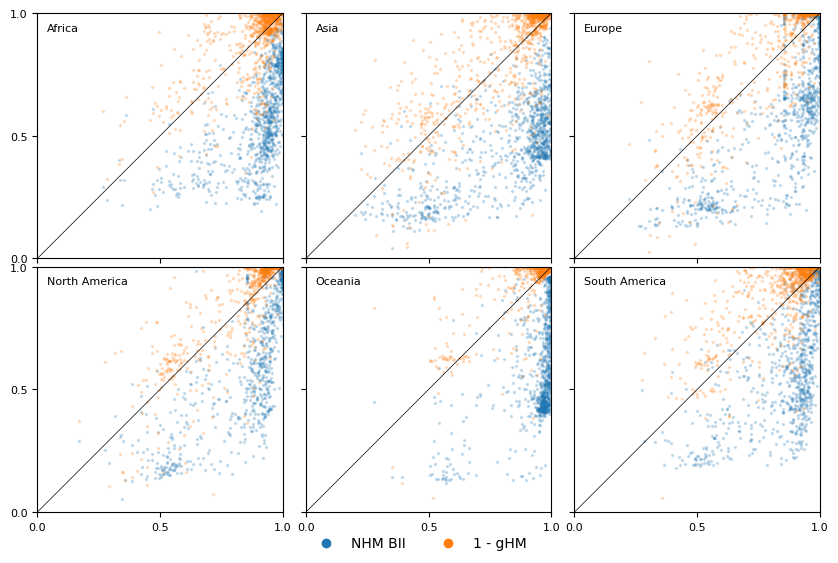

In [2]:
facet_compare(continent, "continent");

## BII vs NHM BII and gHM, by biome

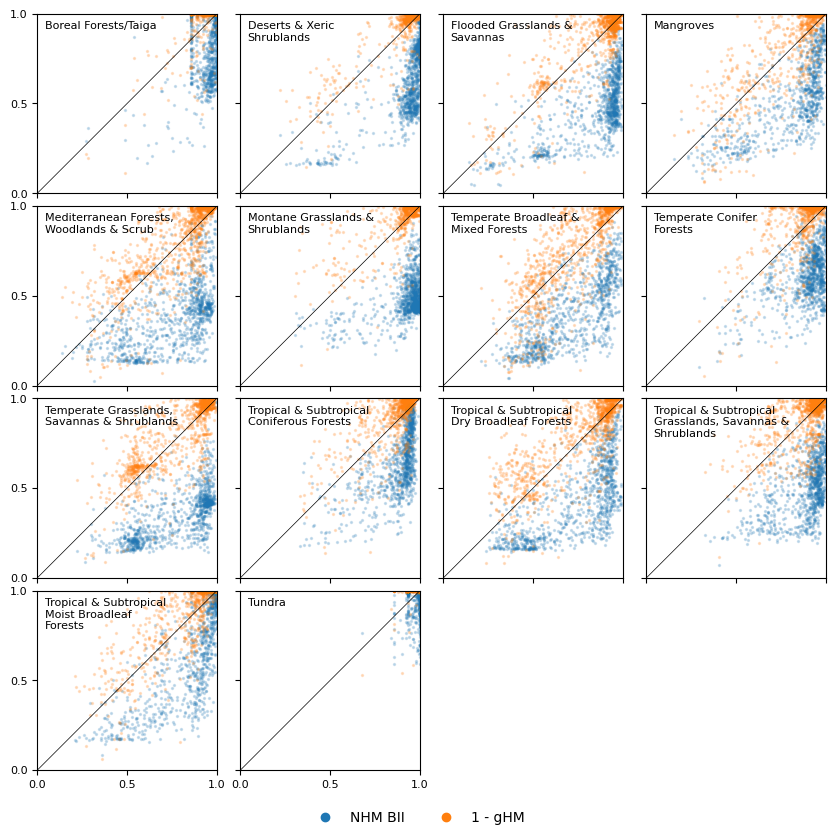

In [3]:
facet_compare(biome, "biome");

## BII4Africa comparison

BII4Africa only covers Africa, so points are taken from the continent sample.

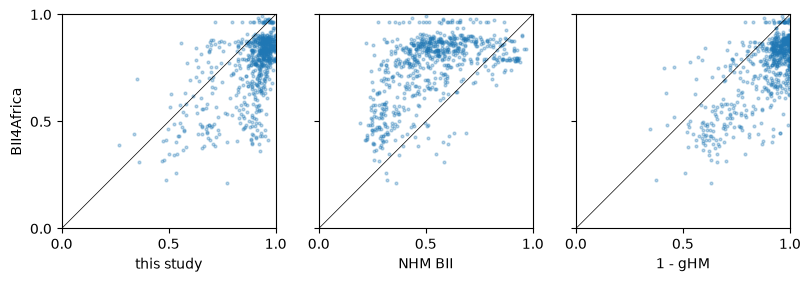

In [51]:
sources = [("bii", "this study"), ("nhm_bii", "NHM BII"), ("ghm", "1 - gHM")]
fig, axes = plt.subplots(1, len(sources), figsize=(A4[0], A4[0] / len(sources)), sharey=True)
for ax, (x, xl) in zip(axes, sources):
    d = continent[[x, "bii_africa"]].dropna()
    r = np.corrcoef(d[x], d["bii_africa"])[0, 1]
    mae = (d[x] - d["bii_africa"]).abs().mean()
    ax.scatter(d[x], d["bii_africa"], s=4, alpha=0.3)
    ax.plot([0, 1], [0, 1], lw=0.5, color="k")
    ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
    #ax.set_title(f"{xl} vs BII4Africa\nr={r:.2f}  MAE={mae:.2f}", fontsize=10)
    ax.set_xlabel(xl, fontsize=10)
axes[0].set_ylabel("BII4Africa", fontsize=10)
fig.tight_layout();

## Correlation and error tables

Pearson `r` and MAE of each comparison dataset against this study, per group and overall.

In [5]:
for name, df, col in [("CONTINENT", continent, "continent"), ("BIOME", biome, "biome")]:
    R, E, M = stat_tables(df, col)
    print(f"\n=== {name}: mean score ===\n{M.to_string()}")
    print(f"\n=== {name}: correlation (r) ===\n{R.to_string()}")
    print(f"\n=== {name}: mean absolute error (MAE) ===\n{E.to_string()}")


=== CONTINENT: mean score ===
               this study  NHM BII  1 - gHM  BII4Africa
Africa              0.908    0.592    0.916       0.756
Asia                0.829    0.471    0.848         NaN
Europe              0.863    0.644    0.880         NaN
North America       0.878    0.680    0.894         NaN
Oceania             0.944    0.618    0.956         NaN
South America       0.881    0.657    0.914         NaN
Overall             0.884    0.610    0.902       0.756

=== CONTINENT: correlation (r) ===
               NHM BII  1 - gHM  BII4Africa
Africa           0.588    0.724       0.588
Asia             0.646    0.822         NaN
Europe           0.793    0.870         NaN
North America    0.775    0.859         NaN
Oceania          0.469    0.802         NaN
South America    0.645    0.769         NaN
Overall          0.644    0.827       0.588

=== CONTINENT: mean absolute error (MAE) ===
               NHM BII  1 - gHM  BII4Africa
Africa           0.317    0.056       0.148

/opt/homebrew/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/homebrew/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/homebrew/lib/python3.11/site-packages/numpy/core/_methods.py:121: Ru